Задача: Написать CNN для классификации цифр датасета MNIST, которая будет обучаться на GPU

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
from tqdm.notebook import tqdm
from IPython.display import clear_output
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import random

Я буду запускать модель на Tesla T4 от Colab, но если вы хотите проверить работоспособность кода на CPU, то код ниже автоматически выберет то, что. доступно

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


Загружаем тренировочную и тестовую части датасета. Сразу же трансформируем изображения в тензоры с помощью ToTensor(), он сразу преобразует тензоры до диапазона [0,1], дополнительно скалировать не придётся

In [ ]:
train_data = datasets.MNIST(root='./data', train = True, download = True, transform = transforms.ToTensor())
test_data = datasets.MNIST(root='./data', train = False, download = True, transform = transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.5MB/s]


Сделаем даталоадеры обоих датасетов и разделим тренировочный на батчи по 128 изображений. Я пробовал значения 64 и ниже – они дают меньшую точность. Значения 256 и выше хоть и ускоряют обучение, но оно становится очень нестабильным (метрики прыгают вверх-вниз)

In [ ]:
train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=len(test_data), shuffle=True)

In [ ]:
print(f"Размер тренировочного набора: {len(train_data)}")
print(f"Размер тестового набора: {len(test_data)}")
print(f"Количество батчей в train: {len(train_loader)}")
print(f"Количество батчей в test: {len(test_loader)}")

Размер тренировочного набора: 60000
Размер тестового набора: 10000
Количество батчей в train: 469
Количество батчей в test: 1


У нас 60к тренировочных картинок и 10к тестовых. В целом данных достаточно, но в случае проблем с точностью можно будет добавить аугментацию

In [ ]:
dataiter = iter(train_loader)
images,labels = next(dataiter)

Посмотрим что вообще внутри датасета

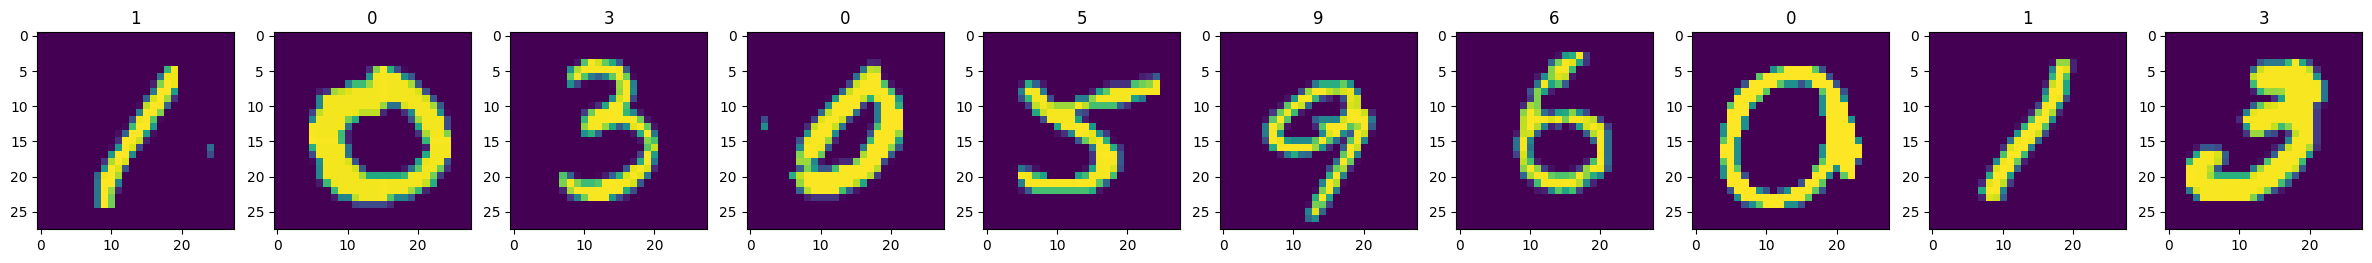

In [ ]:
def show_images(img,labels):
    f, axes = plt.subplots(1,10,figsize = (30,5))
    for i, axis in enumerate(axes):
        axes[i].imshow(np.squeeze(np.transpose(img[i].numpy(),(1,2,0))))
        axes[i].set_title(labels[i].numpy())
    plt.show()
show_images(images,labels)

Изображения цветные, однако для идентификации цифр необходима именно контрастность, поэтому можно сэкономить ресурсы и не проходить через них RGB спектром, зато сделать более глубокую сеть

Сверточная нейронная сеть и классификация. Сделано через контейнеры Sequential. Первая часть извлекает признаки через два свёрточных слоя с пулингом, уменьшая размеры с 28×28 до 7×7. Вторая часть — классификатор из двух полносвязных слоев, преобразующий признаки в 10 классов цифр.

Я выбрал именно такую архитектуру тк мы классифицируем цифры, где явно меньше деталей и сложных комбинаций, чем например, у котов, но при этом всё равно нужна хорошая точность, при этом чтобы обучение занимало не больше 15 секунд на эпоху, тк ждать каждый раз по 10-20 минут не всегда хочется ради +0,3% к accuracy, так еще и ресурсы колаба ограничены

In [ ]:
class Model3(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()

        self.conv_layers = nn.Sequential(
            # Первый сверточный блок
            nn.Conv2d(1, 16, 3, padding=1),  # 1 → 16 каналов
            nn.BatchNorm2d(16),               # BatchNorm после свертки
            nn.ReLU(inplace=True),            # Активация ReLU
            nn.MaxPool2d(2, 2),               # Пулинг 28x28 → 14x14

            # Второй сверточный блок
            nn.Conv2d(16, 32, 3, padding=1),  # 16 → 32 канала
            nn.BatchNorm2d(32),               # BatchNorm
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),               # Пулинг 14x14 → 7x7

            # Третий сверточный блок (добавлен для большей глубины)
            nn.Conv2d(32, 64, 3, padding=1),  # 32 → 64 канала
            nn.BatchNorm2d(64),               # BatchNorm
            nn.ReLU(inplace=True),
            # Здесь НЕ делаем пулинг, чтобы сохранить размер для FC
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),

            # Первый полносвязный слой
            nn.Linear(64 * 7 * 7, 256),       # 64*7*7 = 3136 → 256
            nn.BatchNorm1d(256),              # BatchNorm для полносвязного слоя
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),         # Dropout для регуляризации

            # Второй полносвязный слой
            nn.Linear(256, 128),              # 256 → 128
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.5),   # Меньше dropout в конце

            # Выходной слой
            nn.Linear(128, 10)                # 128 → 10 классов
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

##Расчет размерности карт признаков

(w, h) = (mW + 2p - kW + 1, mH + 2p - kH + 1)


## 1. nn.Conv2d(1, 16, 3, padding=1)

Вход 28×28, kW=3, kH=3, p=1

w = 28 + 2⋅1 - 3 + 1 = 28

h = 28 + 2⋅1 - 3 + 1 = 28

**Выход 28×28**


## 2. nn.MaxPool2d(2, 2)

w = 28/2 = 14  

h = 28/2 = 14

**Выход: 14×14**

## 3. nn.Conv2d(16, 32, 3, padding=1)

Вход 14×14, kW=3, kH=3, p=1

w = 14 + 2⋅1 - 3 + 1 = 14

h = 14 + 2⋅1 - 3 + 1 = 14

**Выход 14×14**

## 4. nn.MaxPool2d(2, 2)

w = 14/2 = 7

h = 14/2 = 7

**Выход 7×7**

## 5. nn.Flatten()

Превращает это всё в 32 × 7 × 7 = 1568 признаков

## 6. nn.Linear(32 * 7 * 7, 128)

Вход 1568

**Выход** 128

## 7. nn.Linear(128, 10)

Вход 128

**Выход 10 (нащи цифры от 0 до 9)**

Отправляем модель на GPU (в моем случае)

In [ ]:
model = Model3().to(device)

Функция которая вычисляет ключевые метрики качества модели классификации: общую точность (accuracy), точность предсказаний (precision), полноту распознавания (recall) и их сбалансированную комбинацию (F1-score). Использует взвешенное усреднение weighted и дает 0 в случае деления на 0

In [ ]:
def calculate_metrics(all_labels, all_preds):
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return accuracy, precision, recall, f1

Обучение на Adam я брал 10 эпох (если брать больше, то обучение занимет несколько минут, а если меньше – точность страдает). LR на первый взгляд очень маленький, но он делает обучение очень стабильным (при больших LR все метрики летают вверх-вниз, но в итоге ты получаешь те же 98.5 +- 0.2 accuracy

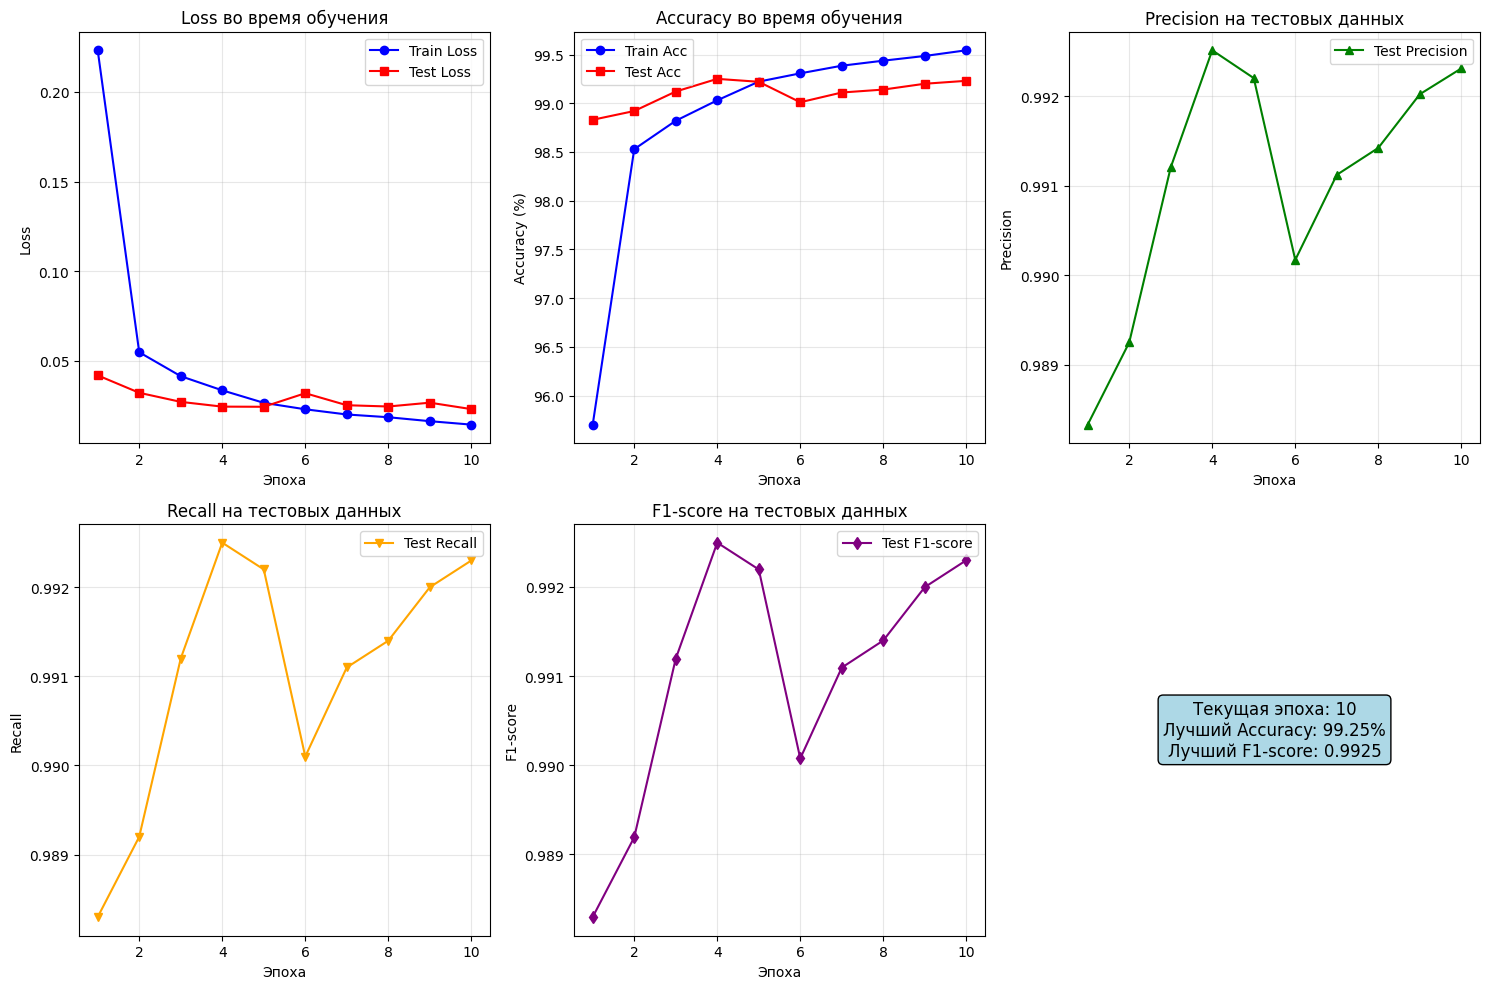


Метрики на последней эпохе

  Accuracy:  0.9923 (99.23%)
  Precision: 0.9923 (99.23%)
  Recall:    0.9923 (99.23%)
  F1-score:  0.9923 (99.23%)


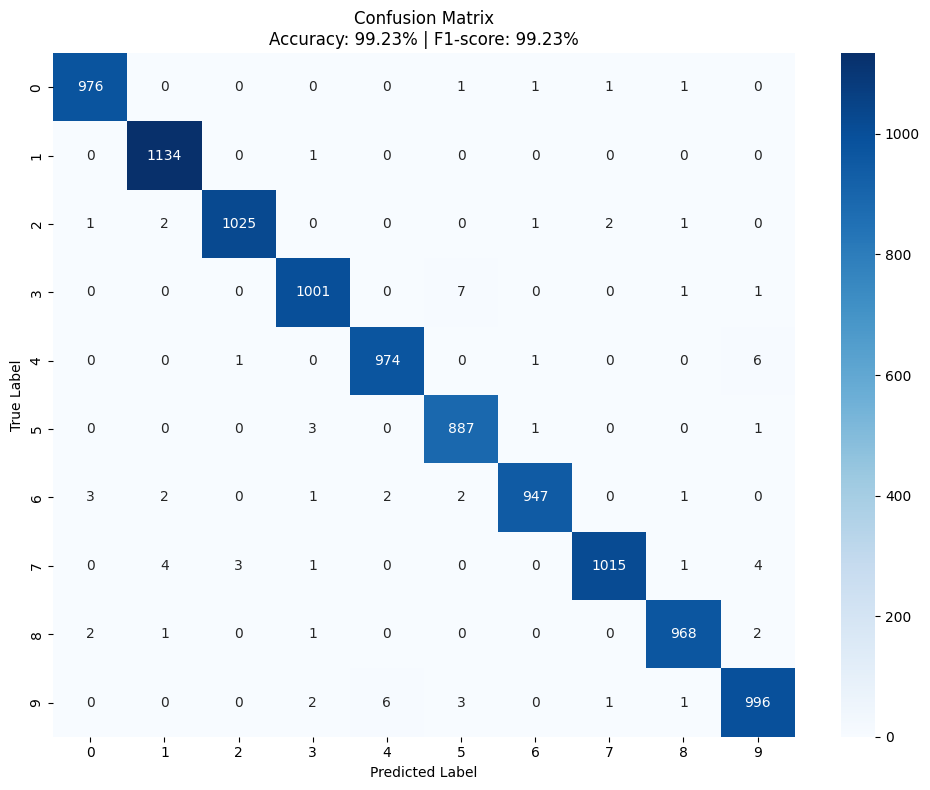


Метрики для каждого класса

Класс      Precision    Recall       F1-score    
0          0.9939       0.9959       0.9949      
1          0.9921       0.9991       0.9956      
2          0.9961       0.9932       0.9947      
3          0.9911       0.9911       0.9911      
4          0.9919       0.9919       0.9919      
5          0.9856       0.9944       0.9900      
6          0.9958       0.9885       0.9921      
7          0.9961       0.9874       0.9917      
8          0.9938       0.9938       0.9938      
9          0.9861       0.9871       0.9866      


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
num_epochs=10

def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=10, device=device):
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': [], 'test_precision': [], 'test_recall': [], 'test_f1': []}
    best_accuracy = 0
    best_f1 = 0
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False)

        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels) # используется loss заданный выше
            loss.backward()
            optimizer.step() # используется optimizer заданный выше
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*train_correct/train_total:.2f}%'})
        avg_train_loss = train_loss / len(train_loader)
        train_accuracy = 100. * train_correct / train_total

        model.eval()
        test_loss = 0.0
        all_preds = []
        all_labels = []
        test_pbar = tqdm(test_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Test]', leave=False)
        with torch.no_grad():
            for images, labels in test_pbar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                test_pbar.set_postfix({
                    'loss': f'{loss.item():.4f}'})
        avg_test_loss = test_loss / len(test_loader)
        # Вычисляем все метрики
        accuracy, precision, recall, f1 = calculate_metrics(all_labels, all_preds)
        test_accuracy = accuracy * 100
        # Сохраняем метрики
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_accuracy)
        history['test_loss'].append(avg_test_loss)
        history['test_acc'].append(test_accuracy)
        history['test_precision'].append(precision)
        history['test_recall'].append(recall)
        history['test_f1'].append(f1)
        # Обновляем лучшие метрики
        if accuracy > best_accuracy:
            best_accuracy = accuracy
        if f1 > best_f1:
            best_f1 = f1
        # Вывод результатов эпохи
        print(f"\nЭпоха [{epoch+1}/{num_epochs}]")
        print(f"  Train: Loss={avg_train_loss:.4f}, Acc={train_accuracy:.2f}%")
        print(f"  Test:  Loss={avg_test_loss:.4f}, Acc={test_accuracy:.2f}%")
        print(f"  Metrics: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")
        print("-" * 60)
        # Отрисовка графиков после каждой эпохи
        clear_output(wait=True)
        plot_training_history(history, epoch+1)
    return history, all_preds, all_labels

def plot_training_history(history, current_epoch):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    epochs = range(1, current_epoch + 1)
    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', marker='o')
    axes[0, 0].plot(epochs, history['test_loss'], 'r-', label='Test Loss', marker='s')
    axes[0, 0].set_xlabel('Эпоха')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Loss во время обучения')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', marker='o')
    axes[0, 1].plot(epochs, history['test_acc'], 'r-', label='Test Acc', marker='s')
    axes[0, 1].set_xlabel('Эпоха')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Accuracy во время обучения')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 2].plot(epochs, history['test_precision'], 'g-', label='Test Precision', marker='^')
    axes[0, 2].set_xlabel('Эпоха')
    axes[0, 2].set_ylabel('Precision')
    axes[0, 2].set_title('Precision на тестовых данных')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    axes[1, 0].plot(epochs, history['test_recall'], 'orange', label='Test Recall', marker='v')
    axes[1, 0].set_xlabel('Эпоха')
    axes[1, 0].set_ylabel('Recall')
    axes[1, 0].set_title('Recall на тестовых данных')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 1].plot(epochs, history['test_f1'], 'purple', label='Test F1-score', marker='d')
    axes[1, 1].set_xlabel('Эпоха')
    axes[1, 1].set_ylabel('F1-score')
    axes[1, 1].set_title('F1-score на тестовых данных')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 2].axis('off')
    axes[1, 2].text(0.5, 0.5, f'Текущая эпоха: {current_epoch}\n'
                    f'Лучший Accuracy: {max(history["test_acc"]):.2f}%\n'
                    f'Лучший F1-score: {max(history["test_f1"]):.4f}',
                    ha='center', va='center', fontsize=12,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
    plt.tight_layout()
    plt.show()

# Обучение

history, all_preds, all_labels = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, device)
accuracy, precision, recall, f1 = calculate_metrics(all_labels, all_preds)

print(f"\nМетрики на последней эпохе\n")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-score:  {f1:.4f} ({f1*100:.2f}%)")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix\nAccuracy: {accuracy*100:.2f}% | F1-score: {f1*100:.2f}%')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
print("\nМетрики для каждого класса\n")
print(f"{'Класс':<10} {'Precision':<12} {'Recall':<12} {'F1-score':<12}")
precision_per_class = precision_score(all_labels, all_preds, average=None, zero_division=0)
recall_per_class = recall_score(all_labels, all_preds, average=None, zero_division=0)
f1_per_class = f1_score(all_labels, all_preds, average=None, zero_division=0)
for i in range(10):
    print(f"{i:<10} {precision_per_class[i]:<12.4f} {recall_per_class[i]:<12.4f} {f1_per_class[i]:<12.4f}")


Видно что adam дает 98,4% accuracy и 0,98 по F1 score. Причем они почти равны тк датасет сбалансирован по классам. По метрикам Precision и Recall для каждого класса можно понять, что модель лучше всего определяет 1, 4 и 6, а хуже всего – 0 и 3. По матрице ошибок видно, что разница между 98% и 100% accuracy это буквально пара изображений в каждом классе, что является скорее элеементом рандома, чем реальной применимостью модели. Думаю если бы датасет был в 100 раз больше, то можно было бы действительно побороться за 99+ процентов accuracy

Кстати исходя из матрицы ошибок видно что модель чаще всего путает 4 и 9, 2 и 7. Всё в целом как в реальной жизни при проверке рукописных работ

**Обучение на SGD**

Тут LR поставлен 0.01 из соображений стабильности обучения. Инерция 0.95 позволяет не откатываться вниз в метриках при достижении accuracy 0.98 на тестовой выборке. Также используется nesterov momentum, сначала делающий шаг и только потом вычисляющий градиент. Именно с этой опцией удалось достичь accuracy 0,99+ на тренировочной выборке

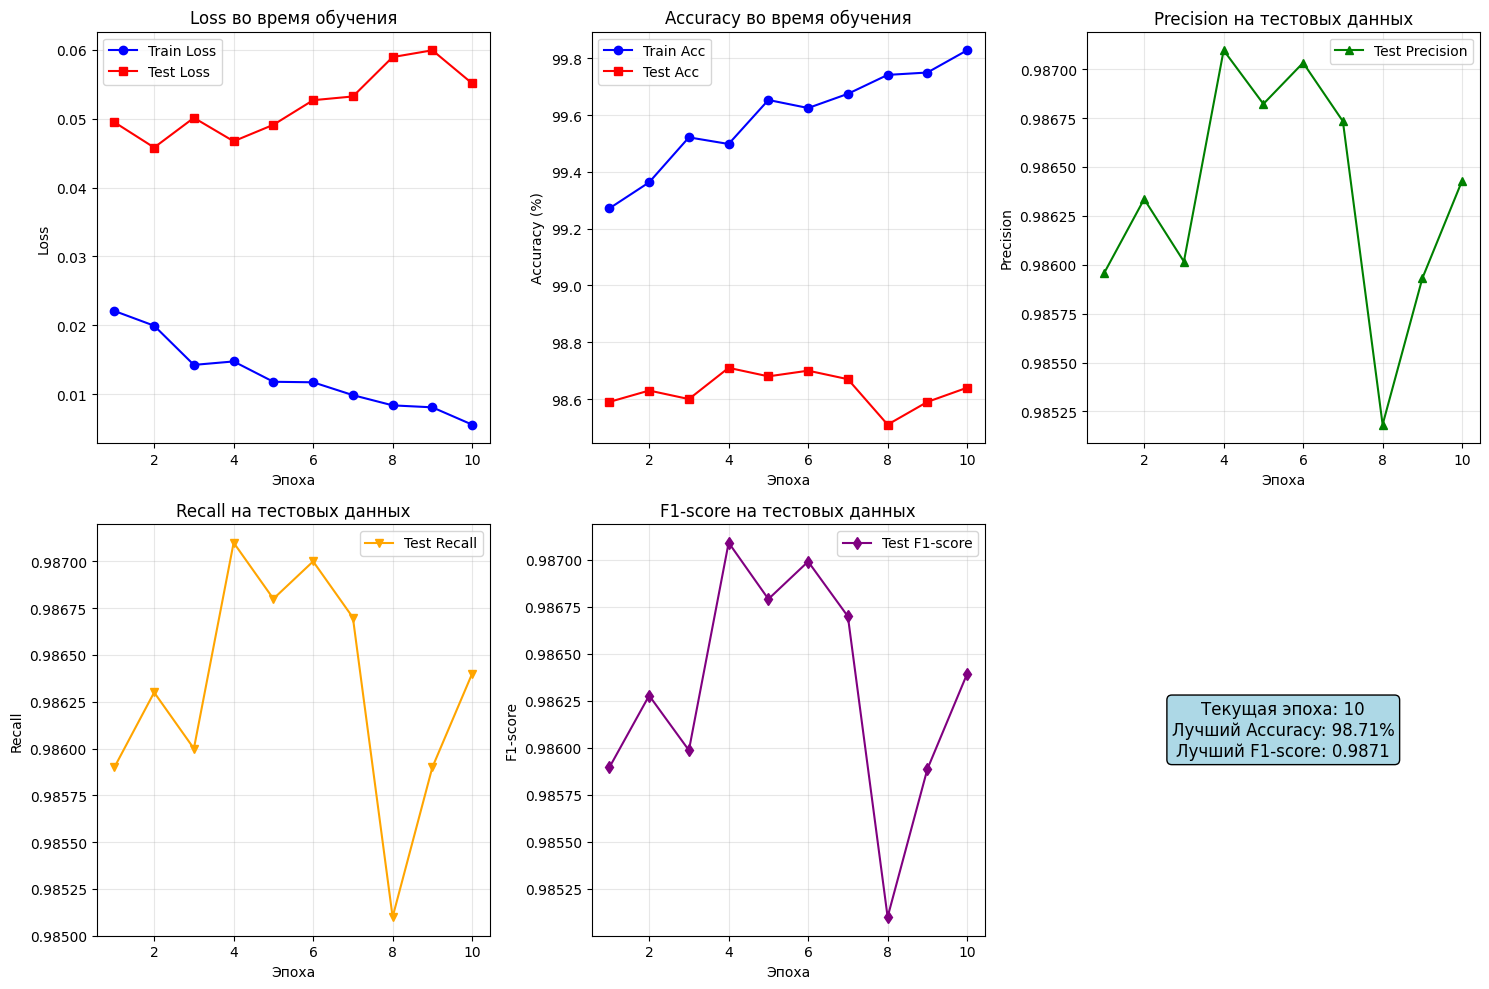


Метрики на последней эпохе

  Accuracy:  0.9864 (98.64%)
  Precision: 0.9864 (98.64%)
  Recall:    0.9864 (98.64%)
  F1-score:  0.9864 (98.64%)


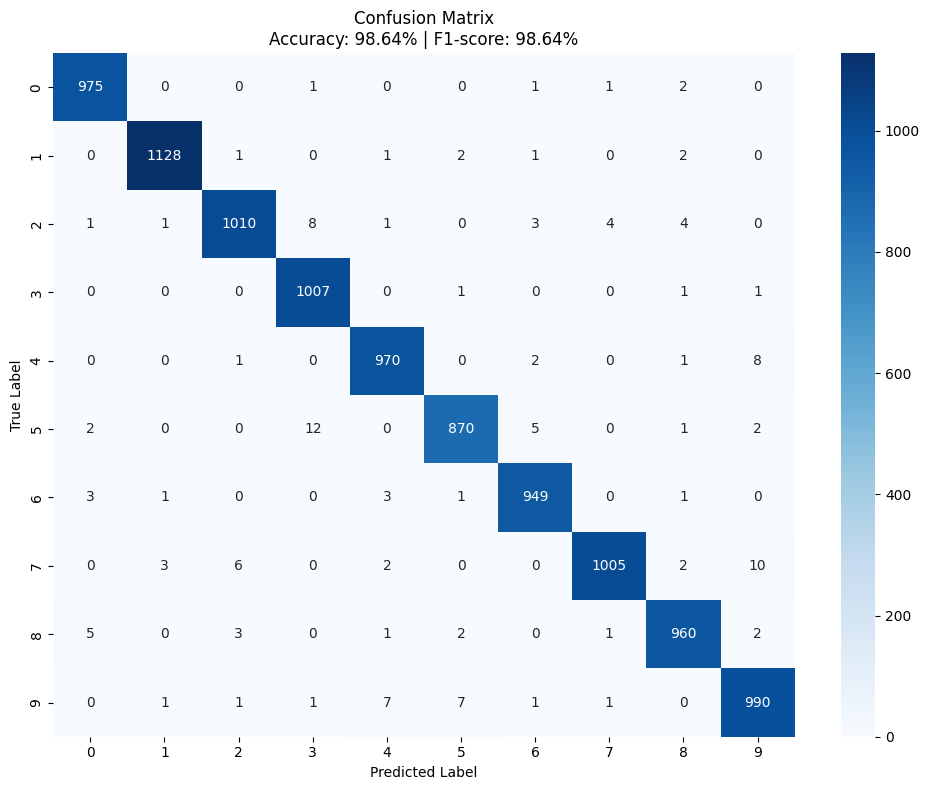


Метрики для каждого класса

Класс      Precision    Recall       F1-score    
0          0.9888       0.9949       0.9919      
1          0.9947       0.9938       0.9943      
2          0.9883       0.9787       0.9834      
3          0.9786       0.9970       0.9877      
4          0.9848       0.9878       0.9863      
5          0.9853       0.9753       0.9803      
6          0.9865       0.9906       0.9885      
7          0.9931       0.9776       0.9853      
8          0.9856       0.9856       0.9856      
9          0.9773       0.9812       0.9792      


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.005, momentum=0.98, nesterov=True)
num_epochs=10

def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=10, device=device):
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': [], 'test_precision': [], 'test_recall': [], 'test_f1': []}
    best_accuracy = 0
    best_f1 = 0
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False)

        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels) # используется loss заданный выше
            loss.backward()
            optimizer.step() # используется optimizer заданный выше
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*train_correct/train_total:.2f}%'})
        avg_train_loss = train_loss / len(train_loader)
        train_accuracy = 100. * train_correct / train_total

        model.eval()
        test_loss = 0.0
        all_preds = []
        all_labels = []
        test_pbar = tqdm(test_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Test]', leave=False)
        with torch.no_grad():
            for images, labels in test_pbar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                test_pbar.set_postfix({
                    'loss': f'{loss.item():.4f}'})
        avg_test_loss = test_loss / len(test_loader)
        # Вычисляем все метрики
        accuracy, precision, recall, f1 = calculate_metrics(all_labels, all_preds)
        test_accuracy = accuracy * 100
        # Сохраняем метрики
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_accuracy)
        history['test_loss'].append(avg_test_loss)
        history['test_acc'].append(test_accuracy)
        history['test_precision'].append(precision)
        history['test_recall'].append(recall)
        history['test_f1'].append(f1)
        # Обновляем лучшие метрики
        if accuracy > best_accuracy:
            best_accuracy = accuracy
        if f1 > best_f1:
            best_f1 = f1
        # Вывод результатов эпохи
        print(f"\nЭпоха [{epoch+1}/{num_epochs}]")
        print(f"  Train: Loss={avg_train_loss:.4f}, Acc={train_accuracy:.2f}%")
        print(f"  Test:  Loss={avg_test_loss:.4f}, Acc={test_accuracy:.2f}%")
        print(f"  Metrics: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")
        print("-" * 60)
        # Отрисовка графиков после каждой эпохи
        clear_output(wait=True)
        plot_training_history(history, epoch+1)
    return history, all_preds, all_labels

def plot_training_history(history, current_epoch):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    epochs = range(1, current_epoch + 1)
    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', marker='o')
    axes[0, 0].plot(epochs, history['test_loss'], 'r-', label='Test Loss', marker='s')
    axes[0, 0].set_xlabel('Эпоха')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Loss во время обучения')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', marker='o')
    axes[0, 1].plot(epochs, history['test_acc'], 'r-', label='Test Acc', marker='s')
    axes[0, 1].set_xlabel('Эпоха')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Accuracy во время обучения')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 2].plot(epochs, history['test_precision'], 'g-', label='Test Precision', marker='^')
    axes[0, 2].set_xlabel('Эпоха')
    axes[0, 2].set_ylabel('Precision')
    axes[0, 2].set_title('Precision на тестовых данных')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    axes[1, 0].plot(epochs, history['test_recall'], 'orange', label='Test Recall', marker='v')
    axes[1, 0].set_xlabel('Эпоха')
    axes[1, 0].set_ylabel('Recall')
    axes[1, 0].set_title('Recall на тестовых данных')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 1].plot(epochs, history['test_f1'], 'purple', label='Test F1-score', marker='d')
    axes[1, 1].set_xlabel('Эпоха')
    axes[1, 1].set_ylabel('F1-score')
    axes[1, 1].set_title('F1-score на тестовых данных')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 2].axis('off')
    axes[1, 2].text(0.5, 0.5, f'Текущая эпоха: {current_epoch}\n'
                    f'Лучший Accuracy: {max(history["test_acc"]):.2f}%\n'
                    f'Лучший F1-score: {max(history["test_f1"]):.4f}',
                    ha='center', va='center', fontsize=12,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
    plt.tight_layout()
    plt.show()

# Обучение

history, all_preds, all_labels = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, device)
accuracy, precision, recall, f1 = calculate_metrics(all_labels, all_preds)

print(f"\nМетрики на последней эпохе\n")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-score:  {f1:.4f} ({f1*100:.2f}%)")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix\nAccuracy: {accuracy*100:.2f}% | F1-score: {f1*100:.2f}%')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
print("\nМетрики для каждого класса\n")
print(f"{'Класс':<10} {'Precision':<12} {'Recall':<12} {'F1-score':<12}")
precision_per_class = precision_score(all_labels, all_preds, average=None, zero_division=0)
recall_per_class = recall_score(all_labels, all_preds, average=None, zero_division=0)
f1_per_class = f1_score(all_labels, all_preds, average=None, zero_division=0)
for i in range(10):
    print(f"{i:<10} {precision_per_class[i]:<12.4f} {recall_per_class[i]:<12.4f} {f1_per_class[i]:<12.4f}")


Тут картина почти та же что и с Adam, но примечательно, что здесь модель также чаще путает 3 и 5  хотя возможно это просто элемент рандома в конкретной итерации

Покажем 10 изображений и их предсказания

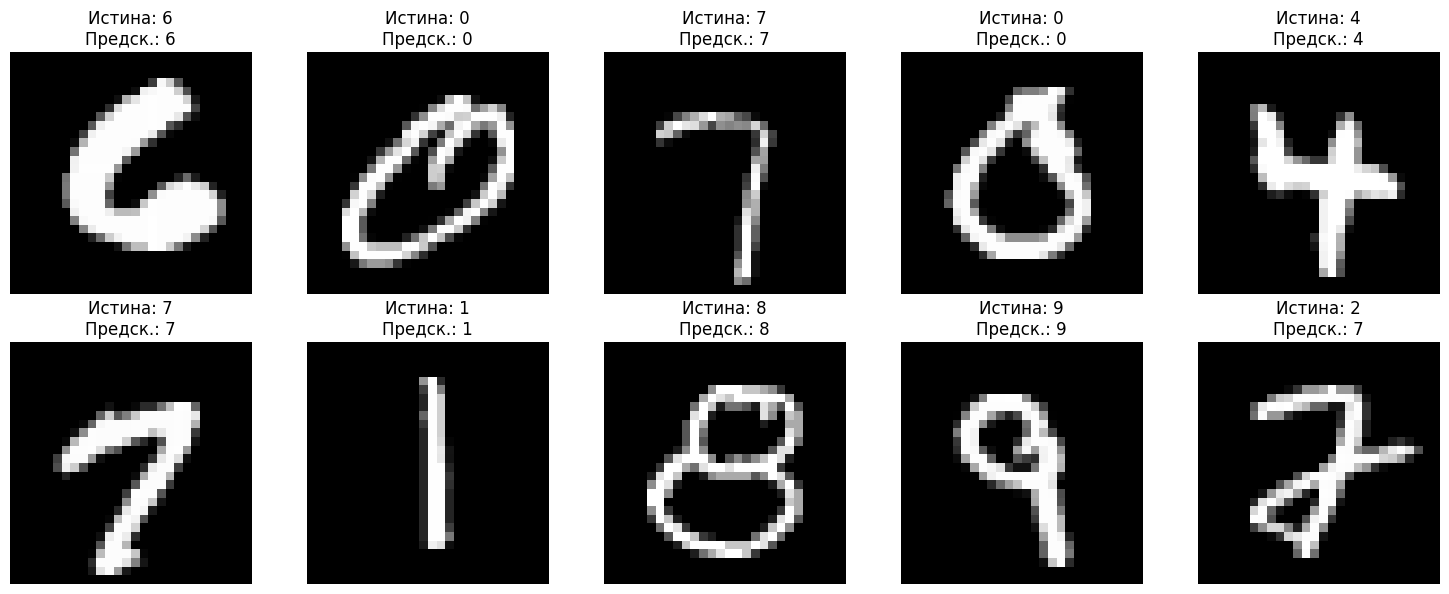

In [ ]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    outputs = model(images)
    _, predictions = torch.max(outputs, 1)
indices = random.sample(range(len(images)), 10)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, idx in enumerate(indices):
    ax = axes[i // 5, i % 5]
    img = images[idx].cpu().squeeze().numpy()
    true_label = labels[idx].item()
    pred_label = predictions[idx].item()
    ax.imshow(img, cmap='gray')
    ax.axis('off')

    ax.set_title(f"Истина: {true_label}\nПредск.: {pred_label}")

plt.tight_layout()
plt.show()

Тут я специально подобрал фотки чтобы хоть что-то вылезло с ошибкой – видно что модель ошиблась спутав 7 и 2, но если честно я сам так иногда пишу двойку, так что я в этом плане выступаю за модель. А если без шуток – думаю более глубокая архитектура смогла бы заметить маленькое соединение средней горизонтальной палочки с основной вертикальной и сказала бы что это 2 а не 7, но нужно больше примеров и времени на обучение

Конечно, для сравнения моделей я использовал немного топорное решение, тк приходилось каждый раз перезапускать код, но зато получилось сравнить результаты кода на разных optimizer

#Итого

**Лучше всего работают – два свёрточных слоя с пулингом + классификатор из двух полносвязных слоев + SGD c lr = 0.01, nesterov momentum = 0.95** на 10 эпохах

P.S Уверен, можно добится 99,5% test accuracy c такими же параметрами, но на 100-200 эпохах, тк думаю эти последние проценты скорее элемент рандома, который вылезет на какой-нибудь эпохе